In [ ]:
# SPDX-License-Identifier: Apache-2.0 AND CC-BY-NC-4.0
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# QEC 101
## Lab 1 - The Basics of Classical and Quantum Error Correction

This lab introduces the basics of error correction (EC). The concepts and terminolofy are presented first, followed by basic examples of classical error correction. The differences between classical and quantum error correction (QEC) are then explained along with a few simple QEC examples.

We assume the reader has some familiarity already with quantum computation and is comfortable with the concepts of qubits, quantum circuits, measurement, Hamiltonians, expectation values, and circuit sampling. The CUDA-Q Academic couse entitled " " provides a walkthrouhg of this prerequisite knowlehe if the reader is new to quantum computing or needs refeeshing.

The list below outlines what you'll be doing in each section of this lab:
* **1.1** Define the basics of EC
* **1.2** Code the classical repetition code
* **1.3** Code the classical Hamming code
* **1.4** Experiment with what makes QEC harder?
* **1.5** Explroe how these challenges are circumvented
* **1.6** Code the quantum repetition code

Learning Objectives:
* Underatand the basic concepts and terminology of EC
* Understand why QEC is harder than classical EC
* Code your first classical and quantum EC examples



Execute the cell below to load all the necessary packages for this lab.

In [ ]:
# Necessary packages


import cudaq
from cudaq import spin
from cudaq.qis import *
import numpy as np
import matplotlib.pyplot as plt
from typing import List

## 1.1 The Basics of Error Correction

Classical [Error correction](https://en.wikipedia.org/wiki/Error_correction_code) (EC) the is practice of redundantly encoding data using additional bits such that if some of the data bits are corrupted (flipped from a 0 to a 1 or vis versa) by external noise, the error can be fixed and the integrity of the original data preserved. There are many potential ways to accomplish this and any specific procedure is refered to as an EC code.

** Image of QR code?** 

It is thanks to EC that you can still watch a DVD that has many scratches, enjoy a clear telephone conversation despite the singal becoming noisy over transmission, or scan a QR code at a restaurant that is partially obscured by a glob of ketchup.  Try it yourself and pull up a QR code.  try covering different parts with your hand and notice that your phone can still inturpret the link despite obfiscation of different parts of the grid. EC is not perfect and has its limits, but in many cases can esentially eliminate any negative effects of noise.

There are five aspects to any general EC procedure: 

1. All EC assumes there is some initial **information** that needs to be preserved or transmitted. The sender and reciepient need to interact with the same infromation even if the way it is stored transforms over and EC procedure.

2.  An EC code then **encodes** the information across $n$ data bits such that $n$ is larger than the minimum number of bits necessary to store the information. For example, 3 bits encoding some binary information.

4. The encoding procedure produces **logical codewords** are the encodings that map to the logical states.  Again in the binary encodings, this defines what is a 0 or a 1 after the encoding process.

5. The encoded data then proceeds throuhg a **noisy channel**.  A noisy channel has some probability of corruptig any of the data bits, flipping them from a 0 to 1 or vis versa.

6.  The recipient then recives the encoded data and needs to **decode** it to determine if an error occured and how thay might fix it. Another way to say this, is ythat the decoder takes the message the recipient recieves and determines which logical codeword "closest" to it. If the decoder produces the correct logical codeword, the EC procedure worked. If not, a **logical error** occured and the recipient incorrectly inturprets the message.

No EC procedure is perfect, but in practice, needs to be "good enough" to ensure that errors do not usually impede the target application. Generally speaking, the more redundancy (extra bits) used in the encoding process, the better the EC will be, but this also comes at a cost of more memory and time to perform more sophisticated decoding. Thus, there is always a tension between the resources available for error correction
and the logical error rate of the procedure and each application needs to strike a balance.

## 1.2 The Repetition Code

The most basic EC code is called the repetition code. or simplicity, consider encoding of a single bit, the the same procedure can be extended for any number of bits. 

The information in this case is a 0 or 1 that needs to be transmitted. The repetion code simply adds more bits which are in the same state. So a 3-bit repetition code encodes the logical 0 state ($0_L$) as 000 and the logical 1 statw ($1_L$) as 111, making 000 and 111 the logical codewords.

Now, assume we want to transmot $0_L$ through a noisy channel such that each data qubit has a probability p=0.1 of flipping erroneously. This means there are eight possible states the encoded message could be in after proceding through the noisy channel. The states can be sorted into two groups. The logical codewords 000 and 111 states are called the codespace while while the rest are the error space as shown in the table below.

The job of the decoder is to map encodings in the error space back to a logical codeword.  This is usualy done through the help of a calculated property that describes the state called a syndrome.  In this case, the syndrome is trivially a majority count of the bits. 

Any single bit error can be correctly identified and corrected, but two or more bit flips will result in a logical error.  There is no way to know for certain if 110 for example is a single error from the $1_L$ codeword or two bit errors from the $0_L$. However a majorit vote greatly reduces the probabiliuty of a logical error. To be very conservativem you could discard results where any error was detected and resent the message.  In this error detection but not correction case,  a logical error will only occuer in the highly unlikley case of three bit flip errors.  However, this is not ideal.

A code can be characterized with the [n,k,d] notation where n is the number of data bits used to encode k logical bits and d is the **distance**.  The distance is te number of errors that must occur for one logical codeword to become the next closest codeword. So this coee is a [3,1,3] code.


THe table below shows the liklihodd of the three scenarios below, notice how the majority vote produces better results that the original 0.1 probability of error.

You now know enough to code up the repetition code. a key principle is the

In [2]:
import random
import matplotlib.pyplot as plt

# function that encodes a single bit as list of repeated bits
def encode(bit, n):
    #TODO

# function that decodes the logical codeword based on the syndrome
def decode(bits):
    #TODO

# Function that takes an encoded bit and randomly flips each data bit with probability p
def transmit(encoded_bit, p_error):
    return [1 - bit if random.random() < p_error else bit for bit in encoded_bit]

# function that simulates and returns logical error rate.
# takes the number of repeted bits (n) and the physical error rate (p) as inputs.
trials = 1000000
def simulate_logical_error_rate(n, p, trials):
    #TODO

# Plot 1: Logical Error Rate vs Physical Error Rate for n = 3 
def plot_logical_vs_physical_error_rate(n, trials=10000):
    p_values = [i * 0.01 for i in range(81)]  
    logical_error_rates = [simulate_logical_error_rate(n, p, trials) for p in p_values]

    plt.figure(figsize=(10, 6))
    plt.plot(p_values, logical_error_rates, marker='o')
    plt.title('Logical Error Rate vs Physical Error Rate')
    plt.xlabel('Physical Error Rate')
    plt.ylabel('Logical Error Rate')
    plt.grid(True)
    plt.show()

# Plot 2: Logical Error Rate vs n 
def plot_logical_vs_repetitions(p, max_n=20, trials=10000):
    n_values = range(1, max_n + 1) 
    logical_error_rates = [simulate_logical_error_rate(n, p, trials) for n in n_values]

    plt.figure(figsize=(10, 6))
    plt.plot(n_values, logical_error_rates, marker='o')
    plt.title('Logical Error Rate vs n')
    plt.xlabel('n')
    plt.ylabel('Logical Error Rate')
    plt.grid(True)
    plt.show()

# Example Usage
n = 3         # Number of repetitions for the first plot
p = 0.1       # Physical error rate for the second plot
trials = 10000

# Generate the plots
plot_logical_vs_physical_error_rate(n, trials)
plot_logical_vs_repetitions(p, max_n=20, trials=trials)


IndentationError: expected an indented block after function definition on line 5 (3519854324.py, line 9)

Notice two things. First, for any physical error rate less than p=.5, the logical error rate is always better than the physical error rate. Second, as $n$ increaces, the logical error rate greatly decreaces, but at rhe cost of additional memory.

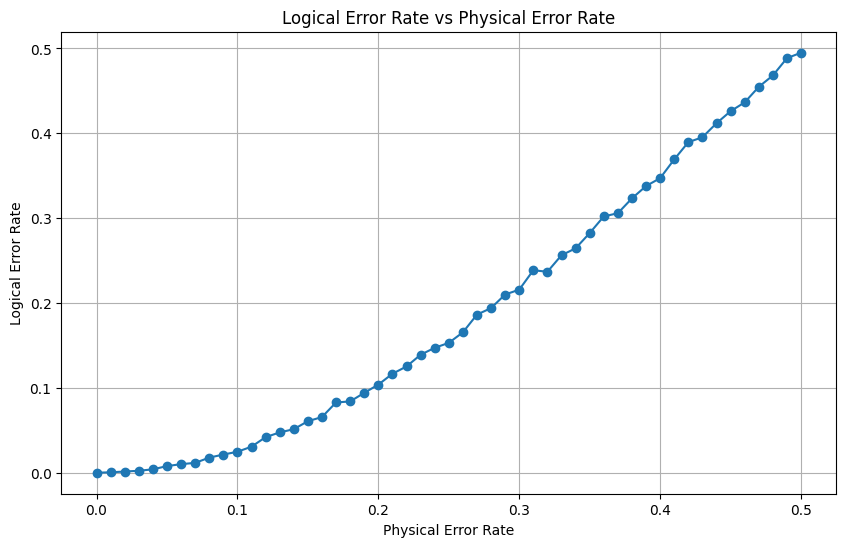

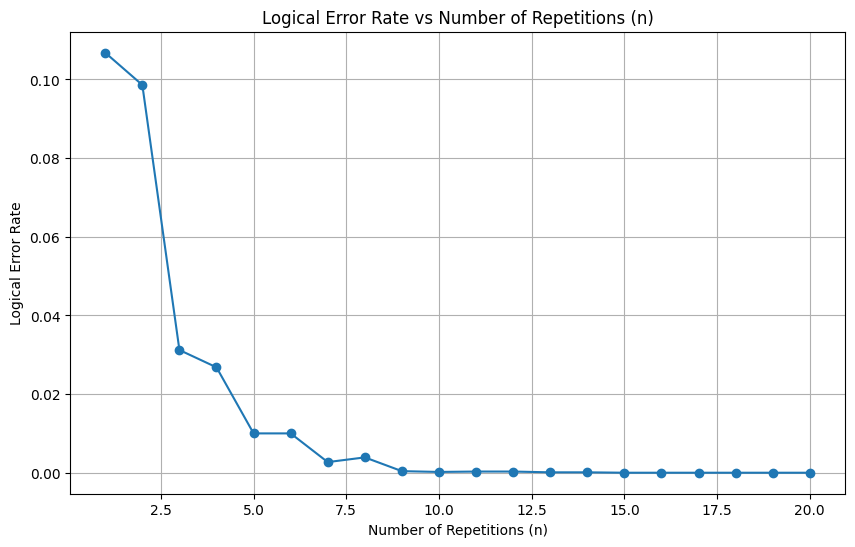

In [4]:
import random
import matplotlib.pyplot as plt

# Function to encode a single bit into n bits
def encode(bit, n):
    return [bit] * n

# Function to decode n bits using majority voting
def decode(bits):
    return 1 if sum(bits) > len(bits) // 2 else 0

# Function to simulate transmission with a given error probability
def transmit(bits, p_error):
    return [1 - bit if random.random() < p_error else bit for bit in bits]

# Function to simulate the logical error rate for n-bit repetition code
def simulate_logical_error_rate(n, p, trials):
    errors = 0
    for _ in range(trials):
        bit = random.randint(0, 1)
        encoded = encode(bit, n)
        received = transmit(encoded, p)
        decoded = decode(received)
        if decoded != bit:
            errors += 1
    return errors / trials

# Plot 1: Logical Error Rate vs Physical Error Rate for fixed n
def plot_logical_vs_physical_error_rate(n, trials=10000):
    p_values = [i * 0.01 for i in range(51)]  # Physical error rates from 0 to 0.3
    logical_error_rates = [simulate_logical_error_rate(n, p, trials) for p in p_values]

    plt.figure(figsize=(10, 6))
    plt.plot(p_values, logical_error_rates, marker='o')
    plt.title('Logical Error Rate vs Physical Error Rate')
    plt.xlabel('Physical Error Rate')
    plt.ylabel('Logical Error Rate')
    plt.grid(True)
    plt.show()

# Plot 2: Logical Error Rate vs Number of Repetitions (n) for fixed physical error rate
def plot_logical_vs_repetitions(p, max_n=20, trials=10000):
    n_values = range(1, max_n + 1)  # Repetition sizes from 1 to max_n
    logical_error_rates = [simulate_logical_error_rate(n, p, trials) for n in n_values]

    plt.figure(figsize=(10, 6))
    plt.plot(n_values, logical_error_rates, marker='o')
    plt.title('Logical Error Rate vs Number of Repetitions (n)')
    plt.xlabel('Number of Repetitions (n)')
    plt.ylabel('Logical Error Rate')
    plt.grid(True)
    plt.show()

# Example Usage
n = 3         # Number of repetitions for the first plot
p = 0.1       # Physical error rate for the second plot
trials = 10000

# Generate the plots
plot_logical_vs_physical_error_rate(n, trials)
plot_logical_vs_repetitions(p, max_n=20, trials=trials)

## 1.3 More Efficient EC Codes (The Hamming Code)


There are many clever ways to improve the efficiency of EC codes. One common way is to make use of a concept called parity checks. Parity checks provide a clever way to index where errors occur, without a brute force statistical approach. 

[The Hamming code](https://en.wikipedia.org/wiki/Hamming_code) is a great example of a parity check code.  The [7,4,3] Hamming code consist of four data bits ($d_1, d_2, d_3, d_4$) and three additional parity check bits ($p_1, p_2, p_3$). We will only consider single bit errors as the distance 3 code can at most detect but not correct two bit errors. 

The Hamming code takes advantage of the fact that the parity bits can encode up to $2^3 = 8$ syndromes, more than enough to consider the seven possible single bit flip errors that cound occur.

This is accomplished by each parity bit encoding a parity, or the mod2 sum of a subset of the data bits.  The Venn diagram below depicts the decoding.  $p_1$ encodes the parity of $d_1, d_4, and d_2$, for example.  


So, if we wanted to send the message 0110, the logical codeword would be 0110110, as the thee parity bits are appended to the original bitstring. 


Errors could occuron any of the data or parity bits. Assume an error occurs on $d_2$ and the recipient recieves 0010110. How can this be computed? To produce the syndrome, the recipient can taker the recieved data bits and compu the expected parity. This is then compared to the parity that was sent and the positions that disagree flag which parity bits flag an error. 


In this case, the recieved message has aparity of 011 which disagrees with 110 such that $p_1$ and $p_3$ are flagged.  This syndrome can only correspond to an error on $d_2$ based ont he Venn diagram.  Similarly, if an error occurd only on $p_2$, only the $p_2$ syndrome would flag. 


In practice, a large message can be broken into blocks and with each encoded with the Hamming code.  The code scales much better than the repetition code.  A Hamming code can be produced for any integrer $r$ greater than 1, such that the code is characterized as [$2^r-1$,$2^r -r -1$,3].  So for a message of size $2^5 -5 -1 = 26$, the Hamming code would require only $2^5-1 =31$ bits while a three bit repetion code would require $26*3 = 78$ bits.


The Hamming code can be formulated in terms of matrix mathematics which you will explore int he coding excercise below.








First, define the generator matrix $G$ such that a dot product between the message and $G$  mod2 performs the valid encoding. Hint: G should be 4x7

In [ ]:
message = np.array([0, 1, 1, 0])

G = np.array([  #FILL IN G])

encoded = np.dot(message, G) % 2

print(encoded)

In [22]:
import numpy as np


message = np.array([0, 1, 1, 0])

G = np.array([
    [1, 0, 0, 0, 1, 1, 0],
    [0, 1, 0, 0, 1, 0, 1],
    [0, 0, 1, 0, 0, 1, 1],
    [0, 0, 0, 1, 1, 1, 1]
])

encoded = np.dot(message, G) % 2

print(encoded)



[0 1 1 0 1 1 0]


Now, define the parity check matrix $H$ such that $Hv \mod 2$ produces a syndrome. 

In [ ]:
recieved = np.array([0, 0, 1, 0,1,1,0])
print(recieved)

# Define the parity check matrix H
H = np.array([
#FILL IN H
])

decoded = np.dot(H, recieved) % 2
print(decoded)

In [23]:

recieved = np.array([0, 0, 1, 0,1,1,0])
print(recieved)


# Define the parity check matrix H
H = np.array([
    [1, 1, 1, 0, 1, 0, 0],
    [1, 1, 0, 1, 0, 1, 0],
    [1, 0, 1, 1, 0, 0, 1]
])

decoded = np.dot(H, recieved) % 2
print(decoded)

[0 0 1 0 1 1 0]
[0 1 1]


## 1.4 What Makes QEC Different/Harder?


